<!-- destinations: github -->
# La théorie par les chiffres — l'éolienne IEA 15 MW

*Séance 0b · DMO-S9 · à lire avec la fiche F1 (aérodynamique et régulation).*

Vous connaissez les formules de la fiche F1. Ce carnet les **calcule une à une, à la main, sur une
autre machine que celle du rendu** (l'IEA 15 MW), puis **confronte chaque résultat à un calcul OpenFAST**
et aux valeurs publiées. Le but n'est pas d'obtenir un chiffre : c'est de savoir **quand un chiffre
calculé à la main est digne de confiance, et d'où vient l'écart quand il ne l'est pas.**

Aucune cellule ne répond à une question notée de votre rendu : la machine est différente.

### Bloc Théorie

1. **Question physique** — Comment une éolienne à vitesse variable et pas variable règle-t-elle sa
   vitesse de rotation, sa puissance et sa poussée selon le vent ? Et jusqu'où une estimation à la main
   (coefficient de puissance, rapport de vitesse en bout de pale, loi de régulation) prédit-elle le
   résultat d'un calcul complet ?
2. **Modèle** — rotor de rayon `R`, vitesse de vent `V`, vitesse de rotation `Ω`. Rapport de vitesse en
   bout de pale `λ = ΩR/V`. Puissance aérodynamique `P = ½ ρ π R² V³ · Cp(λ, β)`, poussée
   `T = ½ ρ π R² V² · Ct(λ, β)`, `β` = angle de calage. Régulation : `Ω` suit `λ*·V/R` entre un
   minimum et un maximum (régions 1½, 2, 2½), puis le calage `β` plafonne la puissance (région 3).
   Fréquences d'excitation du rotor : `1P = Ω/2π` et `3P = 3·1P` (trois pales). **Domaine de validité** :
   vent stationnaire (cisaillement en loi de puissance, sans turbulence), régime établi (transitoire écarté) ; `Cp` et `Ct` lus dans un tableau
   de pales rigides, sans turbulence ni houle ; le modèle OpenFAST est, lui, élastique, avec cisaillement
   et inclinaison de l'arbre.
3. **Ordre de grandeur attendu** — la méthode : pour chaque vent, repérer la région à partir des seuils de
   rotation du contrôleur, calculer `Ω`, puis `P` et `T` avec `Cp` et `Ct` lus au `λ` et au `β` attendus ;
   comparer ensuite à la sortie OpenFAST **moyennée sur le régime établi** et aux valeurs publiées, en
   nommant à chaque fois ce qui est tenu égal et ce qui bouge entre les deux calculs.
4. **Ce que le modèle ne permet pas de conclure** — qu'un vent stationnaire représente un vent
   réel : turbulence, cisaillement et désalignement changent charges et fatigue ; qu'un écart faible sur
   la moyenne valide un modèle (il dit peu des extrêmes ni de la dynamique) ; et qu'un tableau de `Cp`
   issu de pales rigides rende compte de l'élasticité.
5. **Renvois** — fiche F1 (zones de régulation, `Cp(λ)`, équilibre des couples) ; Gaertner et al. 2020,
   NREL/TP-5000-75698, Tab. ES-1 p. iv, §3.1 p. 17, §3.2 p. 18, Fig. 3-1 p. 19, §4 p. 21 ; Jonkman et al.
   2009, NREL/TP-500-38060 (définition des régions de régulation, §7.2 p. 19).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import brentq

# racine du dépôt : on remonte jusqu'au dossier qui contient `s9gm`
RACINE = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "s9gm").is_dir())
sys.path.insert(0, str(RACINE))
from s9gm import lire as s9lire, visu

MODELE = RACINE / "models" / "iea15_monopile"
DOSSIER_MODELE = MODELE / "IEA-15-240-RWT-Monopile"
FIGURES = RACINE / "seances" / "0b" / "figures"
FIGURES.mkdir(exist_ok=True)
ETAT = "OpenFAST v5.0.0, ROSCO 2.10.6, vent stationnaire cisaillé, sans houle"
%matplotlib inline

## 1. Les données de la machine

Deux sources, à ne pas confondre :

- **ce que le contrôleur contient réellement** (le fichier `DISCON.IN` que lit OpenFAST) — c'est lui qui
  fait tourner le calcul ;
- **ce que le rapport publie** (Gaertner et al. 2020) — c'est la référence à laquelle on se compare.

Les grandeurs ci-dessous sont **lues dans les fichiers du modèle**, pas recopiées.

In [2]:
def lire_discon(nom):
    # valeur(s) d'un paramètre de DISCON.IN : « valeur  ! NOM  - commentaire »
    for ligne in (DOSSIER_MODELE / "IEA-15-240-RWT-Monopile_DISCON.IN").read_text().splitlines():
        if "!" in ligne and ligne.split("!")[1].split()[:1] == [nom]:
            return [float(v) for v in ligne.split("!")[0].split()]
    raise KeyError(nom)

def lire_cle(fichier, cle):
    for ligne in (DOSSIER_MODELE / fichier).read_text().splitlines():
        m = ligne.split()
        if len(m) > 1 and m[1] == cle:
            return float(m[0])
    raise KeyError(cle)

R        = lire_discon("WE_BladeRadius")[0]                 # m, rayon utilisé par le contrôleur
lam_opt  = lire_discon("VS_TSRopt")[0]                      # λ* visé en région 2
om_min   = lire_discon("VS_MinOMSpd")[0]                    # rad/s, vitesse minimale
om_nom   = lire_discon("PC_RefSpd")[0]                      # rad/s, vitesse visée par le calage (région 3)
om_vs    = lire_discon("VS_RefSpd")[0]                      # rad/s, vitesse nominale côté couple
P_nom    = lire_discon("VS_RtPwr")[0]                       # W
eta      = lire_cle("IEA-15-240-RWT-Monopile_ServoDyn.dat", "GenEff") / 100
rho      = lire_cle("main.fst", "AirDens")
A        = np.pi * R**2
rpm      = 60 / (2 * np.pi)                                  # rad/s -> tr/min

# table de pas minimal du contrôleur : le pas imposé tant que la puissance n'est pas plafonnée
V_pas = np.array(lire_discon("PS_WindSpeeds"))
beta_min_tab = np.degrees(np.array(lire_discon("PS_BldPitchMin")))

# valeurs publiées (Gaertner 2020, Tab. ES-1 p. iv ; §3.1 p. 17)
# le rapport donne pour Ω max deux arrondis voisins (Tab. ES-1 et §3.1) : on retient celui de Tab. ES-1
publie = {"cut-in (m/s)": 3.0, "vent nominal (m/s)": 10.59, "cut-out (m/s)": 25.0,
          "Ω min (tr/min)": 5.0, "Ω max (tr/min)": 7.56, "λ de conception": 9.0,
          "diamètre du rotor (m)": 240.0, "puissance (MW)": 15.0,
          "frontière 1½/2 (m/s)": 6.98, "frontière 2/3 (m/s)": 10.59}
lu = {"R (m)": R, "λ* (contrôleur)": lam_opt, "Ω min (tr/min)": om_min * rpm,
      "Ω région 3, calage (tr/min)": om_nom * rpm, "Ω nominale, couple (tr/min)": om_vs * rpm, "P nominale (MW)": P_nom / 1e6,
      "rendement générateur": eta, "ρ (kg/m³)": rho}
print("LU DANS LE MODÈLE :")
for k, v in lu.items():
    print(f"  {k:<24}{v:>10.4g}")
print("PUBLIÉ (Gaertner 2020) :")
for k, v in publie.items():
    print(f"  {k:<24}{v:>10.4g}")

LU DANS LE MODÈLE :
  R (m)                          121
  λ* (contrôleur)                  9
  Ω min (tr/min)                   5
  Ω région 3, calage (tr/min)      7.56
  Ω nominale, couple (tr/min)     7.524
  P nominale (MW)                 15
  rendement générateur        0.9576
  ρ (kg/m³)                    1.225
PUBLIÉ (Gaertner 2020) :
  cut-in (m/s)                     3
  vent nominal (m/s)           10.59
  cut-out (m/s)                   25
  Ω min (tr/min)                   5
  Ω max (tr/min)                7.56
  λ de conception                  9
  diamètre du rotor (m)          240
  puissance (MW)                  15
  frontière 1½/2 (m/s)          6.98
  frontière 2/3 (m/s)          10.59


> **Lisez les deux listes côte à côte.** Le rayon `R` du contrôleur (distance du centre du moyeu à la pointe de pale) n'est pas la moitié du diamètre publié. Gardez cet écart en tête : il revient plus loin.

## 2. Le coefficient de puissance `Cp(λ, β)`

Le fichier `Cp_Ct_Cq.IEA15MW.txt` (outil ROSCO, pales rigides ; son en-tête le dit écrit pour la variante flottante du même rotor) donne `Cp`, `Ct` et `Cq` sur une grille de
rapports de vitesse `λ` et d'angles de calage `β`. On l'interpole.

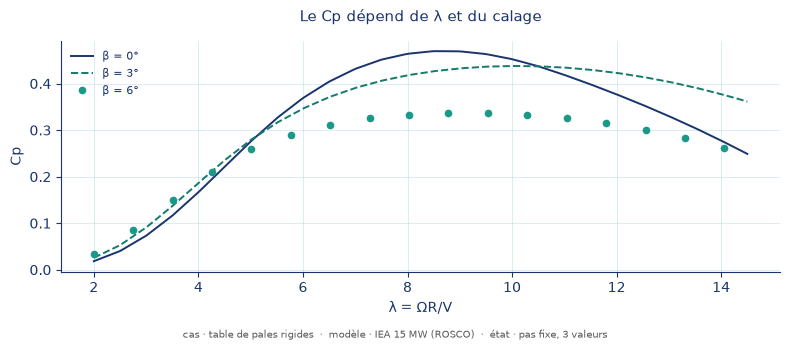

β = 0° : Cp maximal = 0.470 pour λ = 8.53  (λ de conception du contrôleur : 9.0)


In [3]:
def lire_table_rosco(chemin):
    L = [l.strip() for l in Path(chemin).read_text().splitlines()]
    def apres(titre):
        i = next(k for k, l in enumerate(L) if " ".join(l.split()).startswith(titre))
        return i
    beta = np.array(L[apres("# Pitch angle vector") + 1].split(), float)
    tsr = np.array(L[apres("# TSR vector") + 1].split(), float)
    def matrice(titre):
        i = apres(titre) + 1
        while not L[i]:
            i += 1
        return np.array([L[i + k].split() for k in range(len(tsr))], float)
    return tsr, beta, matrice("# Power coefficient"), matrice("# Thrust coefficient")

tsr, beta, CP, CT = lire_table_rosco(MODELE / "IEA-15-240-RWT" / "Cp_Ct_Cq.IEA15MW.txt")
cp = RegularGridInterpolator((tsr, beta), CP, bounds_error=False, fill_value=None)
ct = RegularGridInterpolator((tsr, beta), CT, bounds_error=False, fill_value=None)

lam = np.linspace(tsr[0], tsr[-1], 200)
cas_beta = [0.0, 3.0, 6.0]
courbes = [{"label": f"β = {b:g}°", "x": lam, "y": cp(np.column_stack([lam, np.full_like(lam, b)])),
            "style": ["ligne", "tirets", "points"][i]} for i, b in enumerate(cas_beta)]
courbes[2] |= {"x": lam[::12], "y": courbes[2]["y"][::12]}
fig = visu.tracer_courbes([{"ylabel": "Cp", "courbes": courbes}], xlabel="λ = ΩR/V",
                          cas="table de pales rigides", modele="IEA 15 MW (ROSCO)", etat="pas fixe, 3 valeurs",
                          titre="Le Cp dépend de λ et du calage")
visu.enregistrer(fig, FIGURES / "FIG-S9GM-VISU-003.png", "FIG:S9GM-VISU-003")
plt.show()

# le maximum du Cp à β = 0 : à calculer, pas à lire sur la figure
cp0 = cp(np.column_stack([lam, np.zeros_like(lam)]))
print(f"β = 0° : Cp maximal = {cp0.max():.3f} pour λ = {lam[cp0.argmax()]:.2f}  (λ de conception du contrôleur : {lam_opt})")

**À vous** — changez `beta_essai` puis réexécutez : où se déplace le maximum, et de combien baisse-t-il ?
Le calage est le moyen de **jeter** de la puissance en région 3 : vérifiez-le.

In [4]:
beta_essai = 6.0          # degrés : changez-le (essayez 0, 3, 10, 20)
cpb = cp(np.column_stack([lam, np.full_like(lam, beta_essai)]))
print(f"β = {beta_essai:g}° : Cp maximal = {cpb.max():.3f} pour λ = {lam[cpb.argmax()]:.2f}")
print(f"rapport au maximum à β = 0° : {cpb.max() / cp0.max():.0%}")

β = 6° : Cp maximal = 0.337 pour λ = 9.04
rapport au maximum à β = 0° : 72%


## 3. `Ω(V)` et les régions du contrôleur

Le contrôleur vise `Ω = λ*·V/R`, borné par `Ω_min` et `Ω_nom`. Les seuils de vent s'en déduisent : à vous
de les calculer, **puis de les confronter au rapport**.

In [5]:
def omega_ref(V, R_=None):
    # vitesse de rotation visée (rad/s) : λ*·V/R, bornée entre Ω_min et Ω_nom
    R_ = R if R_ is None else R_
    return np.clip(lam_opt * np.asarray(V, float) / R_, om_min, om_nom)

V_12 = om_min * R / lam_opt        # frontière 1½ / 2 : λ*·V/R atteint Ω_min
V_23 = om_nom * R / lam_opt        # frontière 2 / 3  : λ*·V/R atteint Ω_nom
print(f"avec R du contrôleur ({R:.2f} m) : 1½/2 à {V_12:.2f} m/s ; Ω nominale atteinte à {V_23:.2f} m/s")
print(f"avec R du contrôleur et la consigne de couple VS_RefSpd : Ω nominale côté couple atteinte à {om_vs * R / lam_opt:.2f} m/s")
print(f"avec R = 120 m (demi-diamètre publié) : 1½/2 à {om_min*120/lam_opt:.2f} m/s")
print("publié (Gaertner 2020, §3.1 p. 17) : 6,98 m/s ; vent nominal 10,59 m/s")

avec R du contrôleur (120.97 m) : 1½/2 à 7.04 m/s ; Ω nominale atteinte à 10.64 m/s
avec R du contrôleur et la consigne de couple VS_RefSpd : Ω nominale côté couple atteinte à 10.59 m/s
avec R = 120 m (demi-diamètre publié) : 1½/2 à 6.98 m/s
publié (Gaertner 2020, §3.1 p. 17) : 6,98 m/s ; vent nominal 10,59 m/s


> Deux faits se lisent ici. (1) Le seuil publié 6,98 m/s est retrouvé avec `R = 120 m` et pas avec le rayon du
> contrôleur, alors que le seuil publié 10,59 m/s se retrouve, lui, avec le rayon du contrôleur et la consigne de
> couple `VS_RefSpd` : les deux seuils publiés ne correspondent donc pas à un `R` unique. Pourquoi, nous ne
> l'avons pas établi — un arrondi ou deux définitions de `R` sont des pistes, pas des résultats. (2) La frontière 2/3 par `λ*` tombe tout près du vent nominal : la région
> 2½ de cette machine est quasi inexistante (Gaertner 2020, §3.2 p. 18).

## 4. Puissance, poussée et calage à la main

En région 1½ et 2, le calage est celui que le contrôleur impose (table de pas minimal) ; `Ω` vient du §3 ;
`Cp` et `Ct` se lisent dans le tableau. En région 3, `Ω = Ω_nom` et c'est le calage `β` qui change : on le
**calcule** en demandant que la puissance électrique soit égale à la puissance nominale.

In [6]:
def etat_a_la_main(V):
    # (Ω tr/min, β °, P MW, T kN) d'un vent stationnaire V (m/s)
    om = float(omega_ref(V))
    lam_V = om * R / V
    b_min = float(np.interp(V, V_pas, beta_min_tab))
    P_el = lambda b: eta * 0.5 * rho * A * V**3 * float(cp([[lam_V, b]])[0])
    if P_el(b_min) <= P_nom:                        # puissance non plafonnée : régions 1½ et 2
        b = b_min
    else:                                           # région 3 : on cherche le pas qui plafonne
        b = brentq(lambda b: P_el(b) - P_nom, b_min, 30.0)
    P = P_el(b)
    T = 0.5 * rho * A * V**2 * float(ct([[lam_V, b]])[0])
    return om * rpm, b, P / 1e6, T / 1e3

vents = [5.0, 7.0, 9.0, 10.59, 13.0, 18.0]
main = pd.DataFrame([etat_a_la_main(v) for v in vents], index=vents,
                    columns=["Ω_main (tr/min)", "β_main (°)", "P_main (MW)", "T_main (kN)"])
main.index.name = "V (m/s)"
main.round(3)

,Ω_main (tr/min),β_main (°),P_main (MW),T_main (kN)
V (m/s),,,,
5.00,5.000,2.847,1.381,558.502
7.00,5.000,0.123,4.331,1090.193
9.00,6.394,0.000,9.224,1807.996
10.59,7.524,0.214,15.000,2470.287
13.00,7.560,8.330,15.000,1501.620
18.00,7.560,15.359,15.000,1022.991


## 5. La même chose dans OpenFAST

Six cas à vent stationnaire (loi de puissance, exposant 0,12) (5 ; 7 ; 9 ; 10,59 ; 13 ; 18 m/s), sans houle, générés par
`s9gm.cas` depuis la table `cases/iea15_stationnaire/lct.csv` et lancés par `s9gm.lancer` (600 s simulées
chacun, environ un quart d'heure pour l'ensemble, les six cas tournant en parallèle). Si vous ne les avez pas lancés, le carnet lit à la
place le **jeu de résultats livré** dans `data/` — produit par ces mêmes cas, lu par `s9gm.lire`.

Pour les lancer vous-même : `bash scripts/installer_rosco.sh` (une fois), puis passez `LANCER` à `True`.

In [7]:
FORCER_JEU_LIVRE = bool(__import__("os").environ.get("S9GM_JEU_LIVRE"))   # essai du chemin « après un clone »
LANCER = False   # True : génère et lance les six cas (~15 min, 6 cœurs) ; False : lit les résultats

CALCULS = RACINE / "cases" / "iea15_stationnaire" / "_calculs"
CANAUX = ["Wind1VelX", "RotSpeed", "BldPitch1", "GenPwr", "RotThrust", "RotTorq", "RootMyb1", "TwrBsMyt",
          "RtFldFxh", "RtFldCp", "RtFldCt", "RtVAvgxh", "RtArea"]

if LANCER:
    from s9gm import cas as s9cas, lancer as s9lancer
    dossiers = s9cas.generer_serie(RACINE / "cases" / "iea15_stationnaire" / "lct.csv", DOSSIER_MODELE, CALCULS)
    s9lancer.lancer_serie(dossiers, coeurs=6)

def charger(cas_):
    # série temporelle d'un cas : sortie OpenFAST lue par s9gm.lire, sinon jeu livré dans data/
    sortie = CALCULS / cas_ / "main.outb"
    if sortie.is_file() and not FORCER_JEU_LIVRE:
        df, _ = s9lire.lire(sortie)
        return df, "sortie OpenFAST lue par s9gm.lire"
    livre = pd.read_csv(RACINE / "data" / "iea15_openfast_stationnaire.csv.gz")
    return livre[livre["cas"] == cas_].drop(columns="cas").reset_index(drop=True), "jeu livré (data/), produit par ces cas"

noms = {5.0: "V05_0", 7.0: "V07_0", 9.0: "V09_0", 10.59: "V10_59", 13.0: "V13_0", 18.0: "V18_0"}
series = {v: charger(c)[0] for v, c in noms.items()}
print("source des séries :", charger("V05_0")[1])

source des séries : jeu livré (data/), produit par ces cas


**Écarter le transitoire.** Le rotor part d'une vitesse arbitraire : le contrôleur met du temps à l'amener
à sa vitesse d'équilibre. Regardez la courbe **avant** de choisir le temps à écarter.

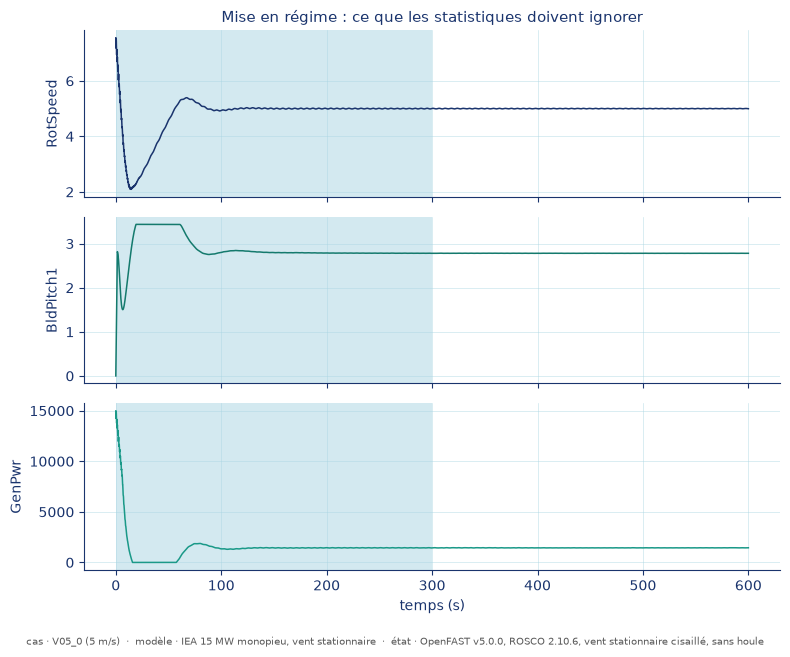

In [8]:
fig = visu.tracer_series(series[5.0], ["RotSpeed", "BldPitch1", "GenPwr"], t_transitoire=300,
                         cas="V05_0 (5 m/s)", modele="IEA 15 MW monopieu, vent stationnaire", etat=ETAT,
                         titre="Mise en régime : ce que les statistiques doivent ignorer")
visu.enregistrer(fig, FIGURES / "FIG-S9GM-VISU-004.png", "FIG:S9GM-VISU-004")
plt.show()

In [9]:
T_TRANSITOIRE = 300      # s : choisi en regardant la courbe ci-dessus ; changez-le et voyez l'effet
stat = {v: s9lire.statistiques(df, CANAUX, t_transitoire=T_TRANSITOIRE) for v, df in series.items()}
of = pd.DataFrame({
    "Ω_OF (tr/min)": [stat[v].loc["RotSpeed", "moyenne"] for v in vents],
    "β_OF (°)": [stat[v].loc["BldPitch1", "moyenne"] for v in vents],
    "P_OF (MW)": [stat[v].loc["GenPwr", "moyenne"] / 1e3 for v in vents],
    "T_OF (kN)": [stat[v].loc["RtFldFxh", "moyenne"] / 1e3 for v in vents],        # poussée aérodynamique (AeroDyn)
    "RotThrust_OF (kN)": [stat[v].loc["RotThrust", "moyenne"] for v in vents]}, index=vents)  # effort sur l'arbre (ElastoDyn)
of.index.name = "V (m/s)"
of.round(3)

,Ω_OF (tr/min),β_OF (°),P_OF (MW),T_OF (kN),RotThrust_OF (kN)
V (m/s),,,,,
5.00,5.000,2.782,1.446,565.886,833.469
7.00,5.000,0.110,4.365,1086.013,1365.827
9.00,6.392,0.000,9.216,1792.557,2088.907
10.59,7.472,0.000,14.739,2439.053,2750.359
13.00,7.560,8.383,15.000,1488.074,1778.878
18.00,7.560,15.411,15.000,1023.667,1305.604


### Les trois sources côte à côte

*Attention : deux « publiés » coexistent. Le rapport (Gaertner 2020) donne un vent nominal de 10,59 m/s et `Ω` max 7,56 tr/min ; le classeur du dépôt du modèle, issu d'un autre calcul (WISDEM, état stationnaire idéalisé), donne 10,66 m/s et 7,52 tr/min. Une part de l'écart « OF / publié » en région 3 vient de là, pas du calcul.*

Troisième source : les valeurs publiées du classeur `Documentation/IEA-15-240-RWT_tabular.xlsx` du dépôt
du modèle (feuille « Rotor Performance »), ici interpolées au vent voulu.

In [10]:
pub = pd.read_csv(RACINE / "data" / "iea15_wisdem_performance.csv")
def publie_a(V, col):
    return float(np.interp(V, pub["V_ms"], pub[col]))
tab = pd.concat([main, of], axis=1)
tab["Ω_pub (tr/min)"] = [publie_a(v, "Omega_rpm") for v in vents]
tab["β_pub (°)"] = [publie_a(v, "pitch_deg") for v in vents]
tab["P_pub (MW)"] = [publie_a(v, "P_MW") for v in vents]
tab["T_pub (kN)"] = [publie_a(v, "T_MN") * 1e3 for v in vents]
ecarts = pd.DataFrame({
    "Ω main/OF (%)": 100 * (tab["Ω_main (tr/min)"] / tab["Ω_OF (tr/min)"] - 1),
    "Ω OF/pub (%)": 100 * (tab["Ω_OF (tr/min)"] / tab["Ω_pub (tr/min)"] - 1),
    "P main/OF (%)": 100 * (tab["P_main (MW)"] / tab["P_OF (MW)"] - 1),
    "P OF/pub (%)": 100 * (tab["P_OF (MW)"] / tab["P_pub (MW)"] - 1),
    "T main/OF (%)": 100 * (tab["T_main (kN)"] / tab["T_OF (kN)"] - 1),
    "T OF/pub (%)": 100 * (tab["T_OF (kN)"] / tab["T_pub (kN)"] - 1)})
display(tab.round(3))
display(ecarts.round(1))

,Ω_main (tr/min),β_main (°),P_main (MW),T_main (kN),Ω_OF (tr/min),β_OF (°),P_OF (MW),T_OF (kN),RotThrust_OF (kN),Ω_pub (tr/min),β_pub (°),P_pub (MW),T_pub (kN)
V (m/s),,,,,,,,,,,,,
5.00,5.000,2.847,1.381,558.502,5.000,2.782,1.446,565.886,833.469,5.000,2.899,1.395,549.387
7.00,5.000,0.123,4.331,1090.193,5.000,0.110,4.365,1086.013,1365.827,5.018,0.031,4.245,1072.665
9.00,6.394,0.000,9.224,1807.996,6.392,0.000,9.216,1792.557,2088.907,6.410,0.000,9.026,1766.750
10.59,7.524,0.214,15.000,2470.287,7.472,0.000,14.739,2439.053,2750.359,7.480,0.000,14.718,2428.861
13.00,7.560,8.330,15.000,1501.620,7.560,8.383,15.000,1488.074,1778.878,7.518,8.247,15.000,1496.167
18.00,7.560,15.359,15.000,1022.991,7.560,15.411,15.000,1023.667,1305.604,7.518,15.437,15.000,1028.746


,Ω main/OF (%),Ω OF/pub (%),P main/OF (%),P OF/pub (%),T main/OF (%),T OF/pub (%)
V (m/s),,,,,,
5.00,-0.0,0.0,-4.5,3.6,-1.3,3.0
7.00,-0.0,-0.3,-0.8,2.8,0.4,1.2
9.00,0.0,-0.3,0.1,2.1,0.9,1.5
10.59,0.7,-0.1,1.8,0.1,1.3,0.4
13.00,-0.0,0.6,-0.0,0.0,0.9,-0.5
18.00,-0.0,0.6,-0.0,0.0,-0.1,-0.5


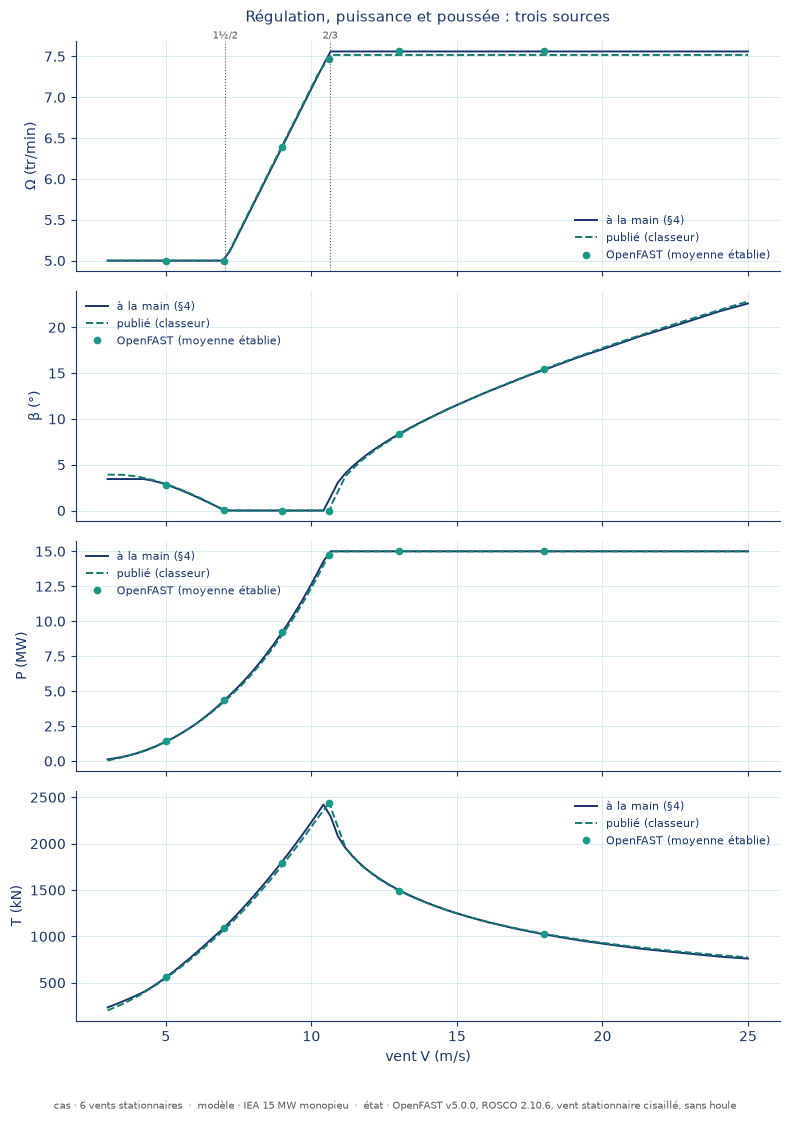

In [11]:
Vf = np.linspace(3, 25, 90)
fine = pd.DataFrame([etat_a_la_main(v) for v in Vf], index=Vf, columns=["om", "b", "P", "T"])
pannos = []
for ylabel, col_main, col_pub, col_of, ech in [("Ω (tr/min)", "om", "Omega_rpm", "Ω_OF (tr/min)", 1),
                                                ("β (°)", "b", "pitch_deg", "β_OF (°)", 1),
                                                ("P (MW)", "P", "P_MW", "P_OF (MW)", 1),
                                                ("T (kN)", "T", "T_MN", "T_OF (kN)", 1)]:
    pannos.append({"ylabel": ylabel,
                   "courbes": [{"label": "à la main (§4)", "x": Vf, "y": fine[col_main], "style": "ligne"},
                               {"label": "publié (classeur)", "x": pub["V_ms"], "y": pub[col_pub] * (1e3 if col_pub == "T_MN" else 1), "style": "tirets"},
                               {"label": "OpenFAST (moyenne établie)", "x": vents, "y": of[col_of], "style": "points"}],
                   "reperes": {"1½/2": V_12, "2/3": V_23} if ylabel.startswith("Ω") else {}})
fig = visu.tracer_courbes(pannos, xlabel="vent V (m/s)", cas="6 vents stationnaires", modele="IEA 15 MW monopieu",
                          etat=ETAT, titre="Régulation, puissance et poussée : trois sources")
visu.enregistrer(fig, FIGURES / "FIG-S9GM-VISU-005.png", "FIG:S9GM-VISU-005")
plt.show()

### D'où viennent les écarts ?

Un écart de quelques pour cent entre deux calculs ne se *constate* pas : il s'attribue. On nomme d'abord ce
qui est **tenu égal** (masse volumique, rendement du générateur, `Ω` et `β` quasi identiques dans les deux
calculs, sauf à 10,59 m/s, au seuil de la région 3 : `Ω` y est 0,7 % plus faible dans OpenFAST et le calage diffère de quelques dixièmes de degré, si bien que le « facteur Cp » de cette ligne mêle écart de point de fonctionnement et écart de modèle) et ce qui **bouge** : le vent que voit réellement le rotor (cisaillement et inclinaison de l'arbre : le
vent moyen sur le disque n'est pas le vent au moyeu), et le coefficient (`Cp` du tableau de pales rigides,
contre `Cp` calculé par AeroDyn). Le calcul complet donne ces deux grandeurs : on peut donc **décomposer**
l'écart de puissance en facteurs, et vérifier que leur produit retrouve l'écart mesuré.

In [12]:
# facteurs de l'écart P_OpenFAST / P_main = (aire) × (vent rotor / vent moyeu)³ × (Cp AeroDyn / Cp tableau)
lignes = {}
for v in [v for v in vents if v <= V_23]:      # région 3 exclue : la puissance y est imposée (voir ci-dessous)
    st = stat[v]
    V_rot, A_ad, cp_ad = st.loc["RtVAvgxh", "moyenne"], st.loc["RtArea", "moyenne"], st.loc["RtFldCp", "moyenne"]
    om_of, b_of = st.loc["RotSpeed", "moyenne"] / rpm, st.loc["BldPitch1", "moyenne"]
    om_m, b_m, *_ = etat_a_la_main(v)
    cp_tab = float(cp([[om_m / rpm * R / v, b_m]])[0])           # Cp du tableau à l'état « à la main »
    f_vent, f_cp, f_aire = (V_rot / v) ** 3, cp_ad / cp_tab, A_ad / A
    lignes[v] = {"vent rotor / moyeu − 1 (%)": 100 * (V_rot / v - 1), "Cp AeroDyn / Cp tableau − 1 (%)": 100 * (f_cp - 1),
                 "facteur vent³": f_vent, "facteur Cp": f_cp, "facteur aire": f_aire,
                 "produit − 1 (%)": 100 * (f_vent * f_cp * f_aire - 1),
                 "P_OF / P_main − 1 (%)": 100 * (of.loc[v, "P_OF (MW)"] / main.loc[v, "P_main (MW)"] - 1)}
decomp = pd.DataFrame(lignes).T
decomp.index.name = "V (m/s)"
decomp.round(3)

,vent rotor / moyeu − 1 (%),Cp AeroDyn / Cp tableau − 1 (%),facteur vent³,facteur Cp,facteur aire,produit − 1 (%),P_OF / P_main − 1 (%)
V (m/s),,,,,,,
5.00,-1.393,9.109,0.959,1.091,1.000,4.592,4.700
7.00,-1.442,4.845,0.957,1.048,1.004,0.730,0.784
9.00,-1.514,4.057,0.955,1.041,1.005,-0.117,-0.082
10.59,-1.581,2.778,0.953,1.028,1.003,-1.756,-1.737


**Lecture.** Les deux colonnes « produit » et « P_OF / P_main » se recouvrent : l'écart de puissance est
*entièrement* expliqué par ces facteurs (le reste, de l'ordre du dixième de pour cent ou moins, est l'écart entre la
puissance d'arbre d'ElastoDyn et la puissance aérodynamique d'AeroDyn ; `Ω`, `β` et le rendement sont déjà pris en
compte ou identiques des deux côtés). Et ce qu'elle montre doit vous faire hésiter : à 7 et 9 m/s, l'accord
entre le calcul à la main et OpenFAST est de l'ordre du pour cent, mais **ce n'est pas parce que le tableau de
`Cp` est exact** — le `Cp` d'AeroDyn est plus grand de plusieurs pour cent, et c'est le vent plus faible vu par le
rotor qui compense. Deux erreurs de signes opposés qui s'annulent donnent un bon accord pour une mauvaise
raison. La cause précise de l'écart de `Cp` (corrections de pointe et de moyeu, modèle de décrochage dynamique,
élasticité des pales, conicité…) **n'est pas établie ici** : c'est une piste, pas un résultat.

À 5 m/s, en région 1½ (`λ` bien au-dessus de l'optimum), la compensation est incomplète et l'écart de
puissance atteint plusieurs pour cent : plus on s'éloigne du `λ` optimal, moins le tableau est fiable.

**En région 3, l'accord sur la puissance n'est pas un test** : elle est égale à la puissance nominale dans les
deux calculs *par construction* (le contrôleur la plafonne, et à la main on a cherché le calage qui la plafonne).
La grandeur à comparer y est le **calage `β`** — c'est lui qui absorbe tous les écarts ci-dessus — et la poussée.

**Deux autres écarts, deux autres causes.**

- *Poussée.* La colonne `RotThrust_OF` (effort sur l'arbre, ElastoDyn) est **bien au-dessus** de la poussée
  aérodynamique `T_OF` (AeroDyn) *et* de la valeur à la main : l'arbre est incliné et il porte le poids du
  rotor, dont une composante s'ajoute à la poussée. Comparez toujours une poussée *aérodynamique* à une poussée
  aérodynamique. Le décalage observé est du même ordre que le poids du rotor projeté sur l'arbre ; il n'est pas
  constant, et son détail n'est pas élucidé ici.
- *Vitesse de rotation à 10,59 m/s.* `Ω` d'OpenFAST est légèrement sous la consigne `λ*·V/R` : le contrôleur est
  proche de la transition entre régions et son lissage de consigne (`SS_Mode = 1` dans `DISCON.IN`) est actif. Que
  ce lissage explique tout l'écart est une hypothèse **non testée** (il faudrait relancer ce cas avec
  `SS_Mode = 0`).

## 6. Fréquences 1P et 3P

`1P = Ω/2π` : une fois par tour ; `3P` : une fois par passage de pale. Calculées à la main, puis cherchées
dans le **spectre** d'une sortie OpenFAST (moment de flexion à l'emplanture d'une pale, poussée du rotor),
sur le régime établi.

V = 13.0 m/s : Ω = 7.56 tr/min  ->  1P = 0.1260 Hz, 3P = 0.3780 Hz


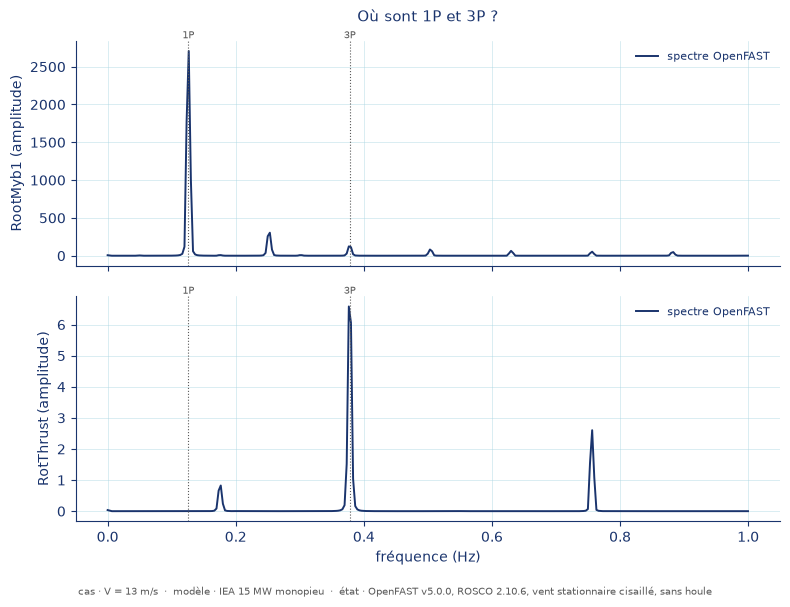

1P : prédit 0.1260 Hz, pic de RootMyb1 à 0.1266 Hz (résolution 0.0033 Hz)
3P : prédit 0.3780 Hz, pic de RotThrust à 0.3765 Hz (résolution 0.0033 Hz)


In [13]:
def spectre(df, canal, t0=T_TRANSITOIRE):
    d = df[df["Time"] >= t0]
    y = d[canal].to_numpy(float)
    y = (y - y.mean()) * np.hanning(len(y))
    dt = float(np.median(np.diff(d["Time"])))
    f = np.fft.rfftfreq(len(y), dt)
    return f, np.abs(np.fft.rfft(y)) * 2 / len(y)

V_spec = 13.0                                   # m/s : changez-le (région 3 : Ω constante)
df_s = series[V_spec]
om_moy = df_s[df_s["Time"] >= T_TRANSITOIRE]["RotSpeed"].mean() / rpm      # rad/s
f1P = om_moy / (2 * np.pi)
print(f"V = {V_spec} m/s : Ω = {om_moy * rpm:.2f} tr/min  ->  1P = {f1P:.4f} Hz, 3P = {3 * f1P:.4f} Hz")

pann = []
for canal in ["RootMyb1", "RotThrust"]:
    f, a = spectre(df_s, canal)
    m = f < 1.0
    pann.append({"ylabel": f"{canal} (amplitude)", "courbes": [{"label": "spectre OpenFAST", "x": f[m], "y": a[m], "style": "ligne"}],
                 "reperes": {"1P": f1P, "3P": 3 * f1P}})
fig = visu.tracer_courbes(pann, xlabel="fréquence (Hz)", cas=f"V = {V_spec:g} m/s", modele="IEA 15 MW monopieu",
                          etat=ETAT, titre="Où sont 1P et 3P ?")
visu.enregistrer(fig, FIGURES / "FIG-S9GM-VISU-006.png", "FIG:S9GM-VISU-006")
plt.show()

# pic le plus haut près de 1P et 3P : la prédiction à la main est-elle bien là ?
for nom, f0, canal in [("1P", f1P, "RootMyb1"), ("3P", 3 * f1P, "RotThrust")]:
    f, a = spectre(df_s, canal)
    m = (f > 0.8 * f0) & (f < 1.2 * f0)
    print(f"{nom} : prédit {f0:.4f} Hz, pic de {canal} à {f[m][a[m].argmax()]:.4f} Hz (résolution {f[1]:.4f} Hz)")

> **Ce qu'il faut retenir.** `1P` et `3P` se calculent avec `Ω` seulement, et le spectre les retrouve : c'est
> la raison pour laquelle la fréquence propre d'une tour ou d'un flotteur doit se tenir à l'écart de ces
> deux bandes (Gaertner 2020, §4 p. 21, pour cette machine). Vous le ferez pour votre propre cas en phase 0.
>
> Un petit pic apparaît aussi sur la poussée vers 0,17 Hz, **entre** 1P et 3P : à vous de l'identifier. Indice :
> Gaertner 2020 (§4 p. 21) et la fiche F1 situent la première fréquence de flexion de la tour de cette machine
> autour de cette valeur ; nous ne l'avons **pas** vérifié sur ce modèle (le fichier de sortie ne donne pas la
> fréquence propre : il faudrait une analyse modale ou un lâcher de tour).

## 7. À vous

Modifiez **un** paramètre à la fois, puis relisez les tableaux et les figures. Notez à chaque fois ce que
vous attendiez avant de regarder.

1. `beta_essai` (§2) : quel calage ramène le maximum de `Cp` au plus près de `λ*` ?
2. `lam_opt` (§1, ligne `lam_opt = …`) : que deviennent les seuils du §3 si le contrôleur vise `λ* = 7` ? Et la
   puissance du §4 en région 2 ?
3. `V_spec` (§6) : que valent `1P` et `3P` en région 2 et en région 3 ? Le rapport entre les deux change-t-il ?
4. `T_TRANSITOIRE` (§5) : que devient la moyenne de `Ω` à 5 m/s si vous n'écartez rien ?

Renvois : fiche F1, minimum vital et ordre de grandeur ; Gaertner et al. 2020 (références ci-dessus).

**Bibliographie.** Gaertner E. et al., *Definition of the IEA 15-Megawatt Offshore Reference Wind Turbine*,
NREL/TP-5000-75698, 2020. Jonkman J. et al., *Definition of a 5-MW Reference Wind Turbine for Offshore System
Development*, NREL/TP-500-38060, 2009. Modèle OpenFAST : dépôt `IEAWindTask37/IEA-15-240-RWT` (Apache-2.0),
adapté à OpenFAST v5.0.0 (voir `PROVENANCE.md`).